In [6]:
import pandas as pd
import joblib
import shap
from sklearn.model_selection import train_test_split

PROCESSED_DATA_PATH = "../data/processed/telco_customer_churn_clean.csv"
MODEL_PATH = "../artifacts/churn_model_package.joblib"
TARGET = "Churn"

In [8]:
df = pd.read_csv(PROCESSED_DATA_PATH)

X = df.drop(columns=[TARGET])
y = (df[TARGET] == "Yes").astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [9]:
package = joblib.load(MODEL_PATH)
model = package["model"]

pipe = model.estimator.estimator

preprocessor = pipe.named_steps["preprocessor"]
xgb_model = pipe.named_steps["model"]

X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed,
    columns=feature_names
)

## Global SHAP plots

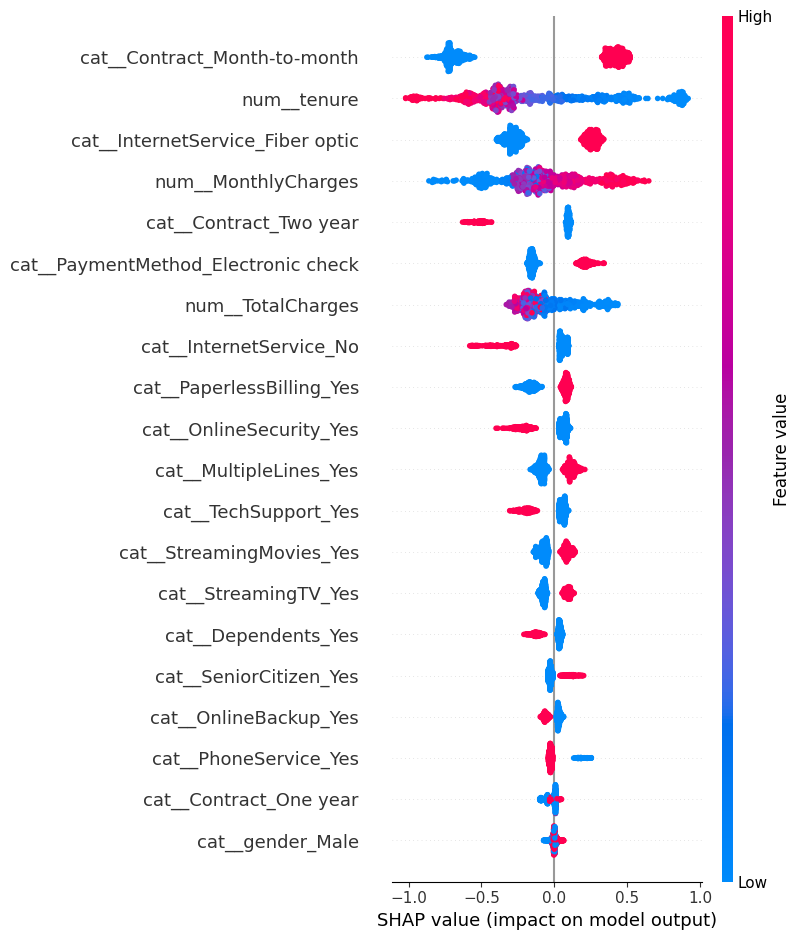

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed_df)

# Beeswarm
shap.summary_plot(shap_values, X_test_transformed_df)

**Observation:** Contract type and tenure are the strongest drivers of churn, with month-to-month contracts, short tenure, fiber internet, and high monthly charges increasing churn risk, while long-term contracts significantly reduce it.

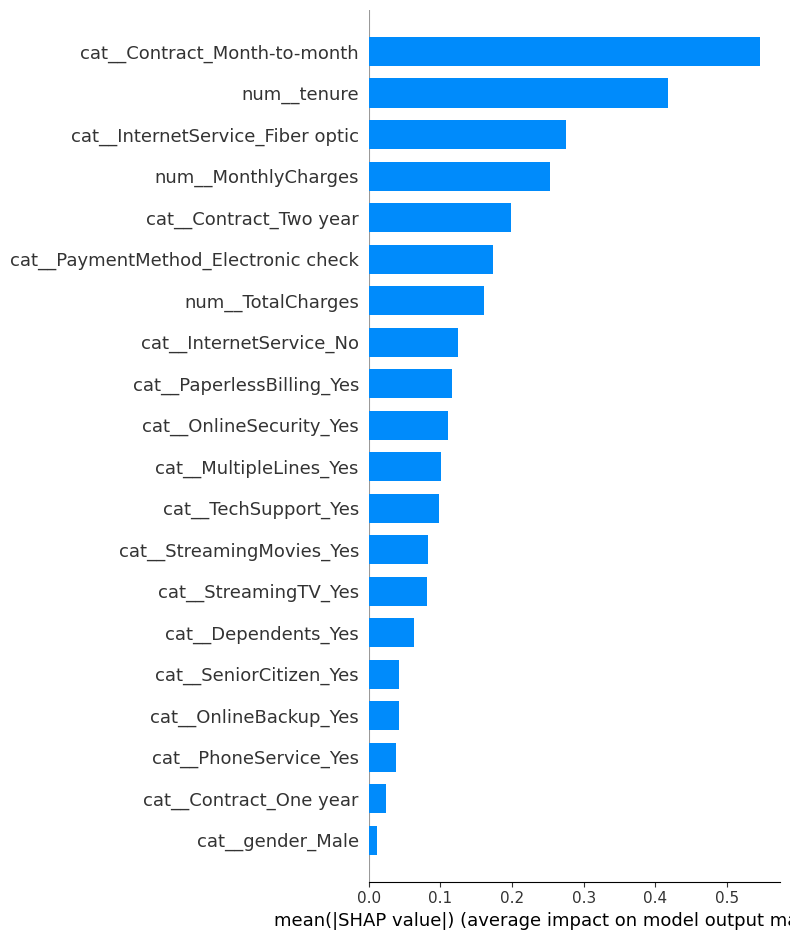

In [12]:
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar")

**Observation:** Month-to-month contracts dominate global feature importance, followed by tenure, fiber internet service, and monthly charges, indicating that contract structure and pricing are primary churn determinants.

## Individual customer explanation

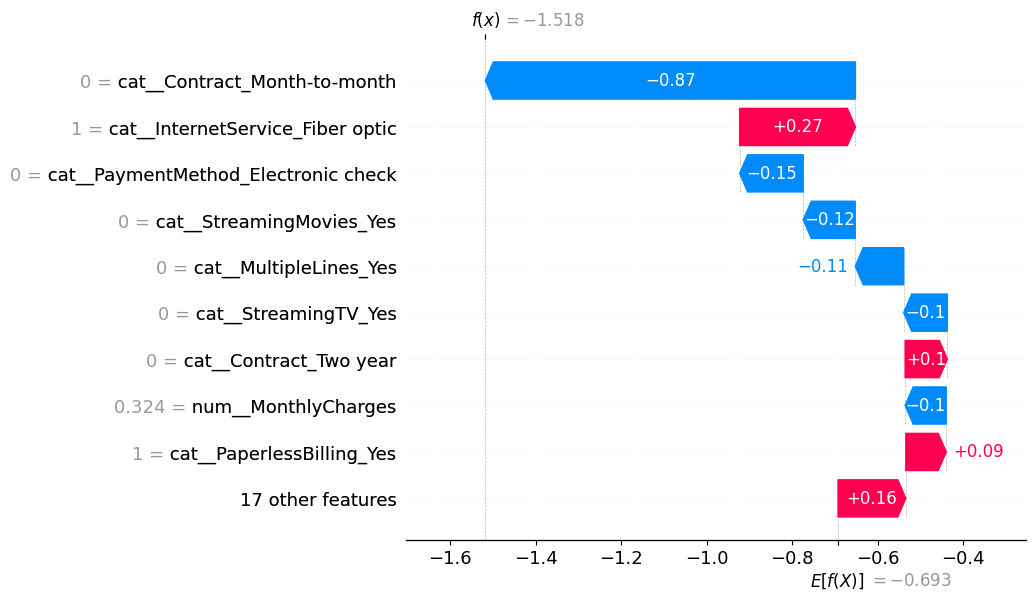

In [13]:
idx = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_transformed_df.iloc[idx],
        feature_names=X_test_transformed_df.columns
    )
)

**Observation:** For this customer, not being on a month-to-month contract and having lower monthly charges strongly reduce churn risk, outweighing moderate risk contributions from fiber internet and paperless billing.